In [41]:
# Импортируем необходимые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from dotenv import load_dotenv
import os

In [42]:
load_dotenv()

API_URL = os.getenv("API_URL")
DATE_BEGIN = os.getenv("DATE_BEGIN")
DATE_END = os.getenv("DATE_END")

print(f"API_URL: {API_URL}")
print(f"Период: {DATE_BEGIN} - {DATE_END}")

# Функция для получения данных через API
def get_data(endpoint: str, start: str, end: str) -> pd.DataFrame:
    response = requests.get(f"{API_URL}/{endpoint}", params={"begin": start, "end": end})
    if response.status_code == 200:
        df = pd.DataFrame(response.json())
        print(f" Загружено {len(df)} записей из {endpoint}")
        return df
    else:
        print(f" Ошибка загрузки {endpoint}: {response.status_code}")
        return pd.DataFrame()

# Загружаем данные
visits_raw = get_data("visits", DATE_BEGIN, DATE_END)
regs_raw = get_data("registrations", DATE_BEGIN, DATE_END)

# Проверяем, что данные загрузились
print(f"\n visits_raw: {visits_raw.shape}")
print(f" regs_raw: {regs_raw.shape}")

API_URL: https://data-charts-api.hexlet.app
Период: 2023-03-01 - 2023-09-01
 Загружено 263459 записей из visits
 Загружено 21836 записей из registrations

 visits_raw: (263459, 4)
 regs_raw: (21836, 5)


In [43]:
charts_path = "./charts"
os.makedirs(charts_path, exist_ok=True)
print(f"Папка для графиков: {os.path.abspath(charts_path)}")

Папка для графиков: C:\Users\Marishka\Desktop\project 3\charts


In [44]:
visits_clean = visits_raw[~visits_raw["user_agent"].str.contains("bot", case=False, na=False)].copy()
print(f"После удаления ботов: {len(visits_clean)} записей")

После удаления ботов: 256077 записей


In [45]:
visits_clean["datetime"] = pd.to_datetime(visits_clean["datetime"], utc=True, errors="coerce")
regs_raw["datetime"] = pd.to_datetime(regs_raw["datetime"], utc=True, errors="coerce")
print(" Даты преобразованы")

 Даты преобразованы


In [46]:
visits_last = visits_clean.sort_values("datetime").drop_duplicates(subset="visit_id", keep="last")
visits_last["date_group"] = visits_last["datetime"].dt.date
regs_raw["date_group"] = regs_raw["datetime"].dt.date
print(f"Уникальных визитов: {len(visits_last)}")

Уникальных визитов: 138703


In [47]:
visits_agg = visits_last.groupby(["date_group", "platform"]).size().reset_index(name="visits")
regs_agg = regs_raw.groupby(["date_group", "platform"]).size().reset_index(name="registrations")

print(f"Уникальных дат: {visits_agg['date_group'].nunique()}")
print(f"Платформы: {visits_agg['platform'].unique()}")

Уникальных дат: 184
Платформы: ['android' 'ios' 'web']


In [49]:
conversion_df = pd.merge(visits_agg, regs_agg, on=["date_group", "platform"], how="left")
conversion_df["registrations"] = conversion_df["registrations"].fillna(0)
conversion_df["conversion"] = (conversion_df["registrations"] / conversion_df["visits"] * 100)

print(f" Конверсия рассчитана")
print(conversion_df.head())

 Конверсия рассчитана
   date_group platform  visits  registrations  conversion
0  2023-03-01  android      75             61   81.333333
1  2023-03-01      ios      22             18   81.818182
2  2023-03-01      web     279              8    2.867384
3  2023-03-02  android      67             59   88.059701
4  2023-03-02      ios      31             24   77.419355


In [51]:
conversion_df.to_json("./conversion.json")
print(" conversion.json сохранен")

 conversion.json сохранен


In [52]:
# Загружаем рекламные данные из локального файла
ads_raw = pd.read_csv("./ads.csv")
print(f" ads_raw: {ads_raw.shape}")

ads_raw["date"] = pd.to_datetime(ads_raw["date"])
ads_raw["date_group"] = ads_raw["date"].dt.date

ads_agg = ads_raw.groupby(["date_group", "utm_campaign"])["cost"].sum().reset_index()

# Объединяем с конверсией
ads_metrics = pd.merge(conversion_df, ads_agg, left_on="date_group", right_on="date_group", how="left")
ads_metrics["cost"] = ads_metrics["cost"].fillna(0)
ads_metrics["utm_campaign"] = ads_metrics["utm_campaign"].fillna("none")

ads_metrics = ads_metrics.sort_values(["date_group", "platform"]).reset_index(drop=True)
ads_metrics.to_json("./ads.json")

print(f" Данные с рекламой сохранены в ads.json")
print(f"Всего записей: {len(ads_metrics)}")

 ads_raw: (159, 5)
 Данные с рекламой сохранены в ads.json
Всего записей: 552


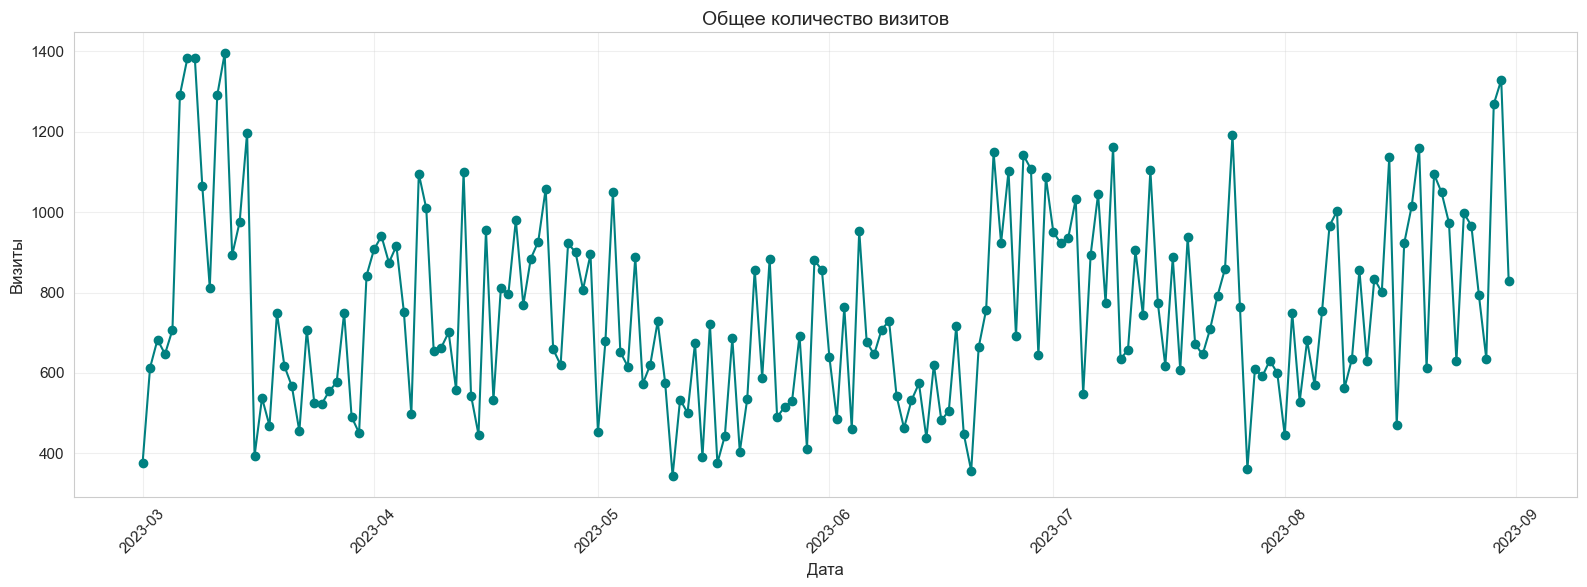

 График total_visits.png сохранен


In [53]:
visits_daily = ads_metrics.groupby("date_group")["visits"].sum().reset_index()

plt.figure(figsize=(16,6))
plt.plot(visits_daily["date_group"], visits_daily["visits"], marker="o", color="teal")
plt.title("Общее количество визитов")
plt.xlabel("Дата")
plt.ylabel("Визиты")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{charts_path}/total_visits.png")
plt.show()
print(" График total_visits.png сохранен")

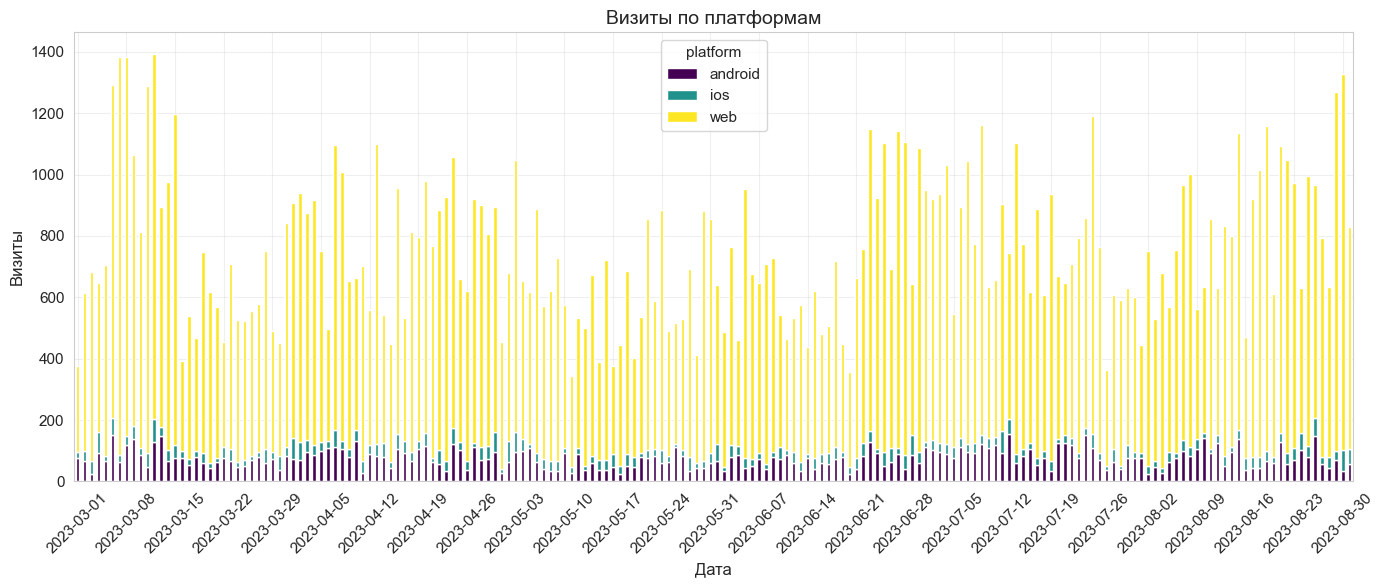

 График visits_by_platform.png сохранен


In [54]:
visits_platform = conversion_df.pivot(index="date_group", columns="platform", values="visits").fillna(0)

ax = visits_platform.plot(kind="bar", stacked=True, figsize=(14,6), colormap="viridis")
plt.title("Визиты по платформам")
plt.xlabel("Дата")
plt.ylabel("Визиты")
ax.set_xticks(ax.get_xticks()[::7])
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{charts_path}/visits_by_platform.png")
plt.show()
print(" График visits_by_platform.png сохранен")

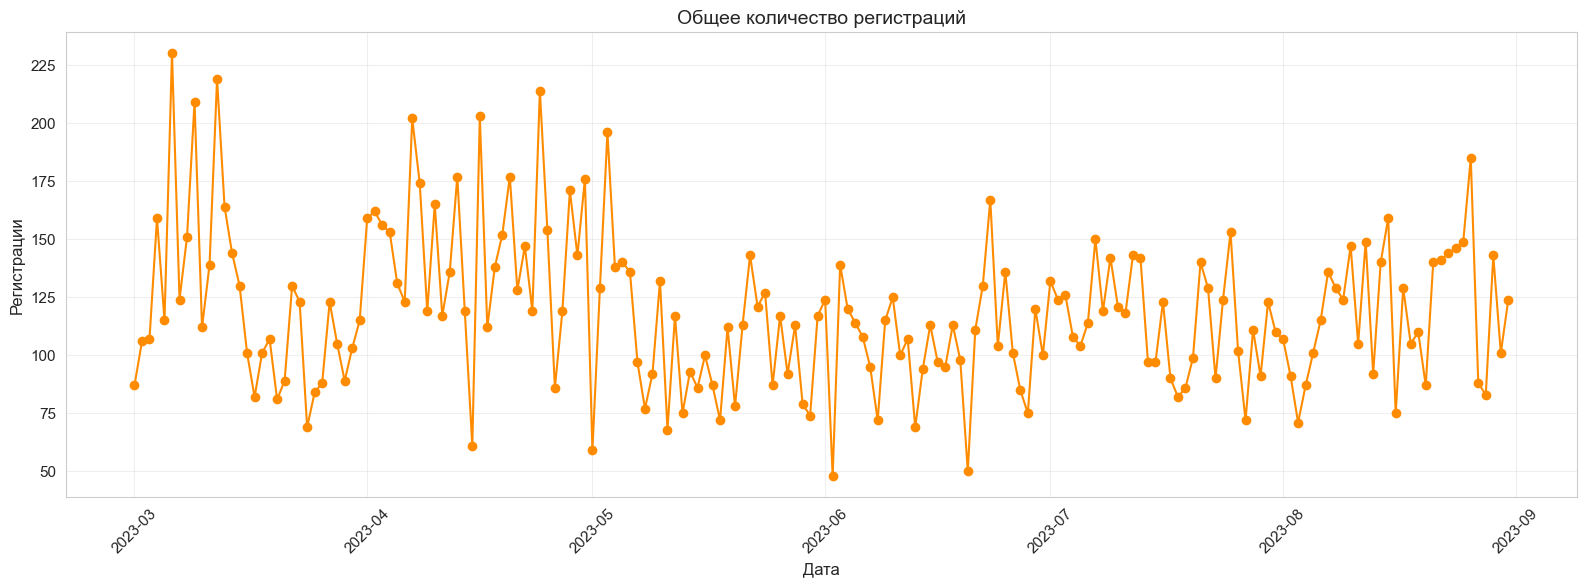

 График total_regs.png сохранен


In [55]:
regs_daily = ads_metrics.groupby("date_group")["registrations"].sum().reset_index()

plt.figure(figsize=(16,6))
plt.plot(regs_daily["date_group"], regs_daily["registrations"], marker="o", color="darkorange")
plt.title("Общее количество регистраций")
plt.xlabel("Дата")
plt.ylabel("Регистрации")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{charts_path}/total_regs.png")
plt.show()
print(" График total_regs.png сохранен")

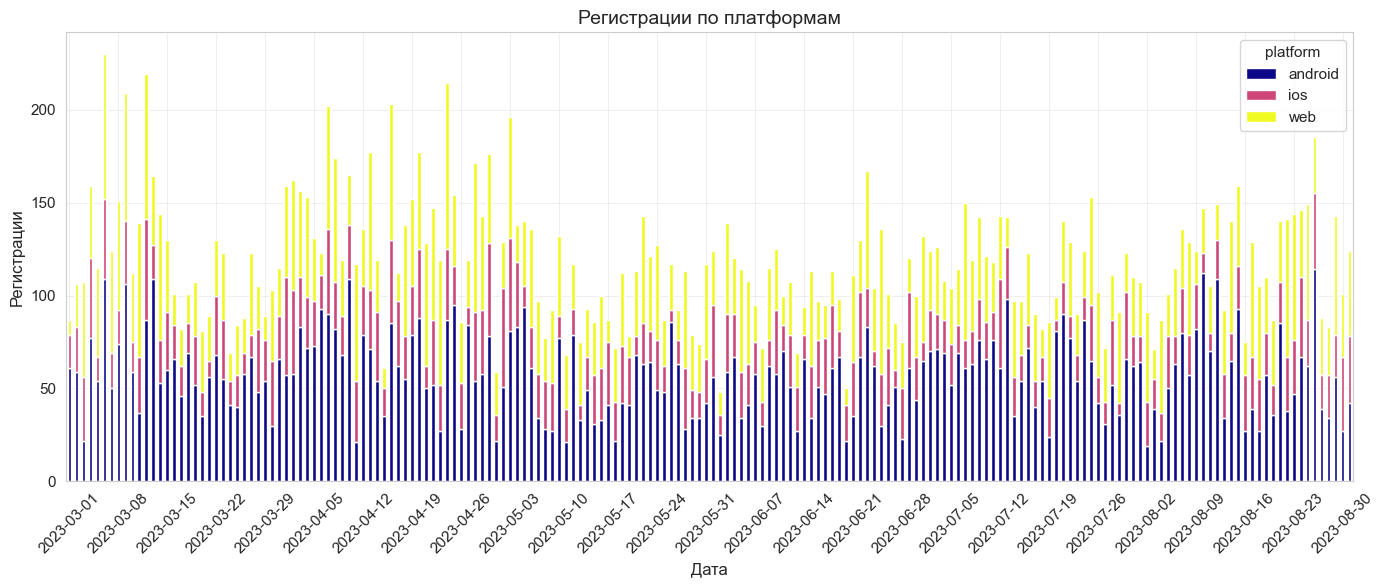

 График regs_by_platform.png сохранен


In [56]:
regs_platform = conversion_df.pivot(index="date_group", columns="platform", values="registrations").fillna(0)

ax = regs_platform.plot(kind="bar", stacked=True, figsize=(14,6), colormap="plasma")
plt.title("Регистрации по платформам")
plt.xlabel("Дата")
plt.ylabel("Регистрации")
ax.set_xticks(ax.get_xticks()[::7])
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{charts_path}/regs_by_platform.png")
plt.show()
print(" График regs_by_platform.png сохранен")

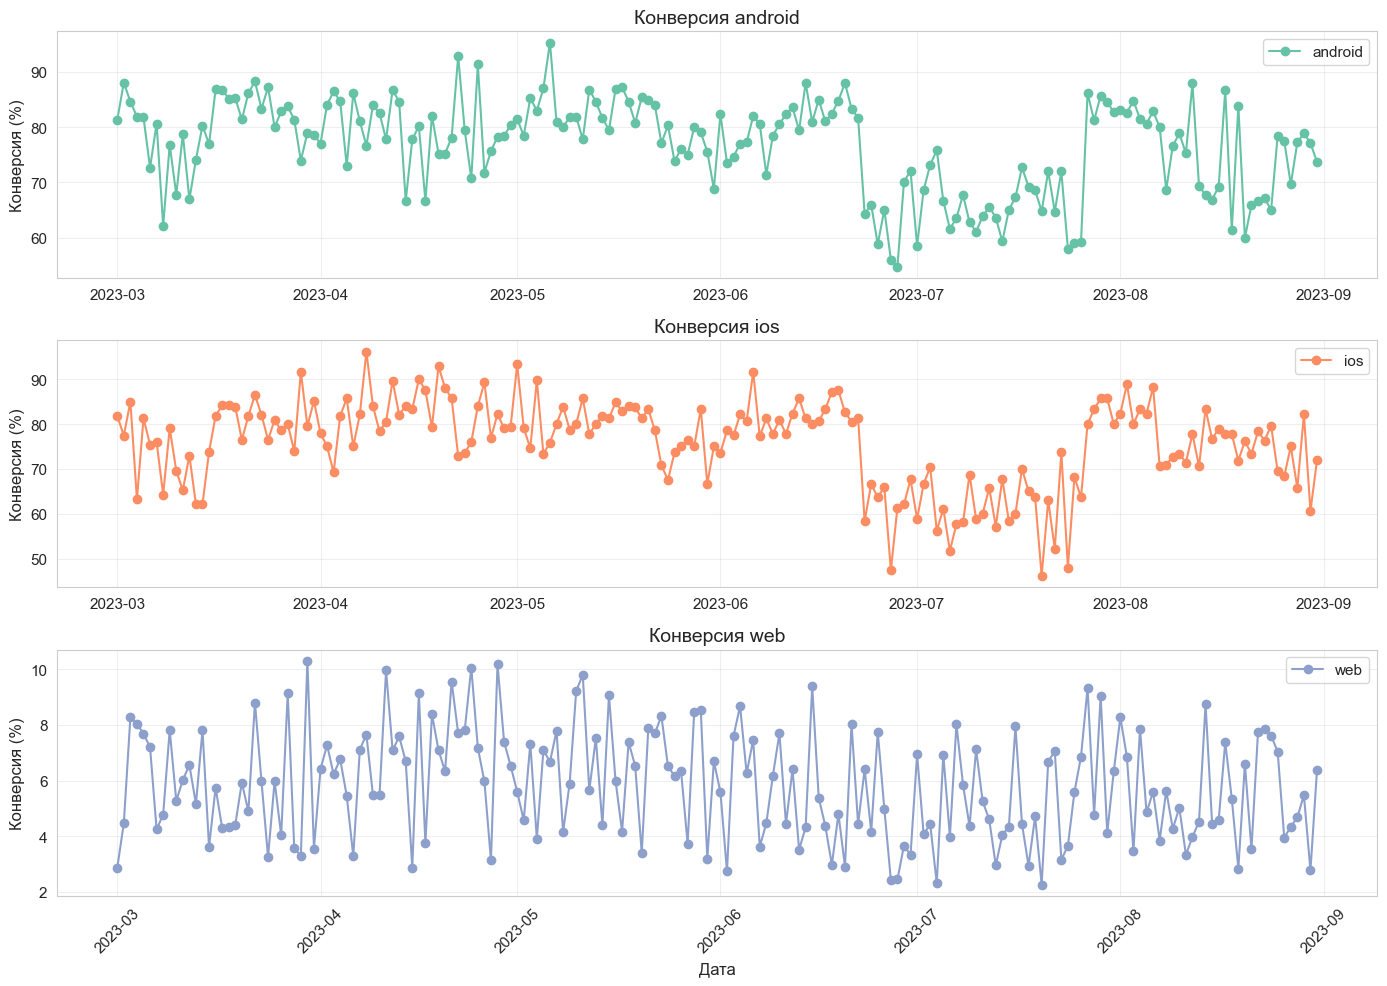

 График conversion_by_platform.png сохранен


In [57]:
conv_platform = conversion_df.pivot(index="date_group", columns="platform", values="conversion").fillna(0)

plt.figure(figsize=(14,10))
for i, platform in enumerate(conv_platform.columns):
    plt.subplot(len(conv_platform.columns), 1, i+1)
    plt.plot(conv_platform.index, conv_platform[platform], marker="o", label=platform, 
             color=sns.color_palette("Set2")[i])
    plt.title(f"Конверсия {platform}")
    plt.ylabel("Конверсия (%)")
    plt.grid(alpha=0.3)
    plt.legend()

plt.xlabel("Дата")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{charts_path}/conversion_by_platform.png")
plt.show()
print(" График conversion_by_platform.png сохранен")

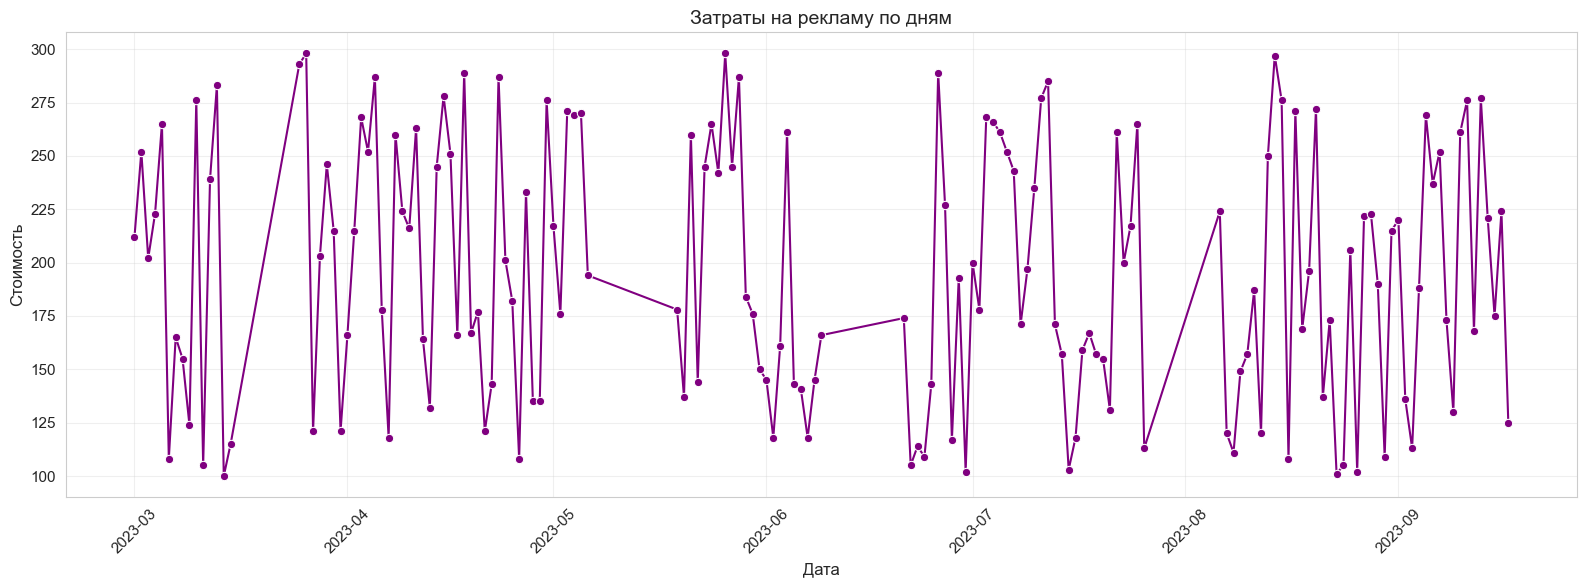

 График ads_costs.png сохранен


In [58]:
ads_costs = ads_raw.groupby("date_group")["cost"].sum().reset_index()

plt.figure(figsize=(16,6))
sns.lineplot(data=ads_costs, x="date_group", y="cost", marker="o", color="purple")
plt.title("Затраты на рекламу по дням")
plt.xlabel("Дата")
plt.ylabel("Стоимость")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{charts_path}/ads_costs.png")
plt.show()
print(" График ads_costs.png сохранен")

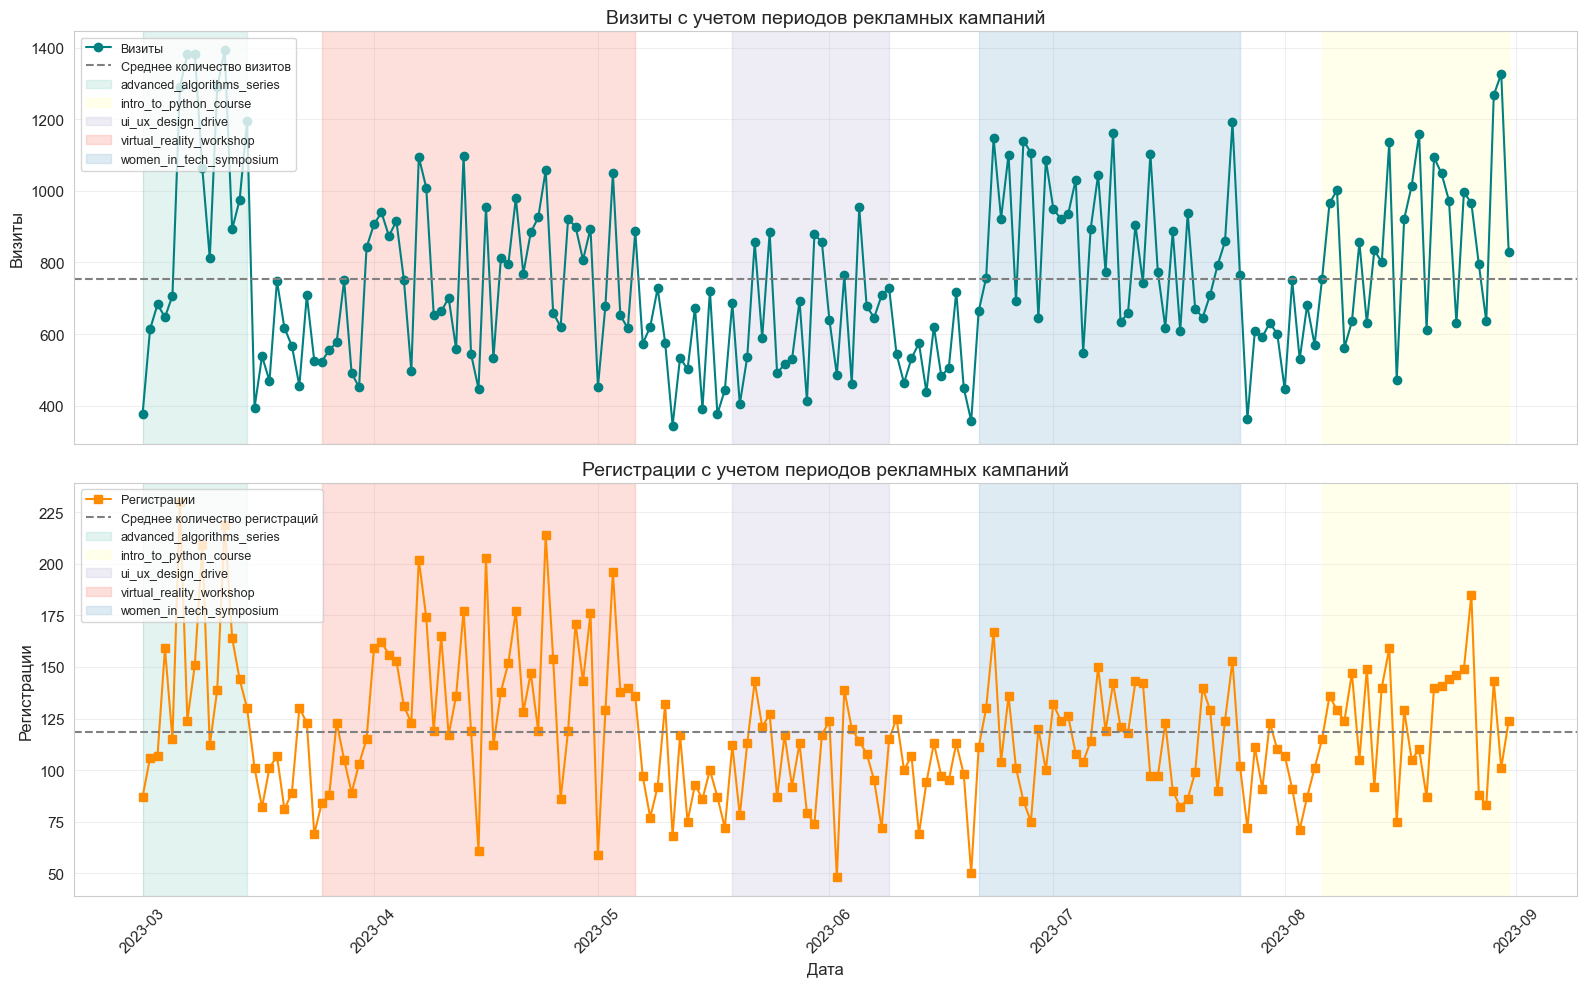

 График visits_regs_with_ads.png сохранен

 Анализ завершен! Все графики сохранены в папке 'charts'


In [59]:
visits_daily = ads_metrics.groupby("date_group")["visits"].sum().reset_index()
regs_daily = ads_metrics.groupby("date_group")["registrations"].sum().reset_index()

ads_by_day = ads_metrics.groupby(["date_group", "utm_campaign"])["cost"].sum().reset_index()
ads_by_day = ads_by_day[ads_by_day["utm_campaign"] != "none"]

fig, ax = plt.subplots(2, 1, figsize=(16,10), sharex=True)

ax[0].plot(visits_daily["date_group"], visits_daily["visits"], marker="o", linestyle="-", color="teal", label="Визиты")
ax[0].axhline(visits_daily["visits"].mean(), color="gray", linestyle="--", label="Среднее количество визитов")

colors = plt.cm.Set3.colors
for i, (campaign, group) in enumerate(ads_by_day.groupby("utm_campaign")):
    start = group["date_group"].min()
    end = group["date_group"].max()
    ax[0].axvspan(start, end, alpha=0.25, color=colors[i % len(colors)], label=campaign)

ax[0].set_title("Визиты с учетом периодов рекламных кампаний", fontsize=14)
ax[0].set_ylabel("Визиты")
ax[0].legend(loc="upper left", fontsize=9)
ax[0].grid(alpha=0.3)

ax[1].plot(regs_daily["date_group"], regs_daily["registrations"], marker="s", linestyle="-", color="darkorange", label="Регистрации")
ax[1].axhline(regs_daily["registrations"].mean(), color="gray", linestyle="--", label="Среднее количество регистраций")

for i, (campaign, group) in enumerate(ads_by_day.groupby("utm_campaign")):
    start = group["date_group"].min()
    end = group["date_group"].max()
    ax[1].axvspan(start, end, alpha=0.25, color=colors[i % len(colors)], label=campaign)

ax[1].set_title("Регистрации с учетом периодов рекламных кампаний", fontsize=14)
ax[1].set_ylabel("Регистрации")
ax[1].set_xlabel("Дата")
ax[1].legend(loc="upper left", fontsize=9)
ax[1].grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{charts_path}/visits_regs_with_ads.png")
plt.show()
print(" График visits_regs_with_ads.png сохранен")

print("\n" + "="*50)
print(" Анализ завершен! Все графики сохранены в папке 'charts'")
print("="*50)